In [ ]:
#---------------------------------------
# Step 1: Imports & GPU Setup
#---------------------------------------

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#---------------------------------------
# Step 2: Data Preprocessing & Custom PyTorch Dataset
#---------------------------------------

In [30]:
# 1. Load Data as DataFrame
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# 2. Feature Engineering (Ratio Features)
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']
df['PopulationPerHousehold'] = df['Population'] / df['AveOccup']

# Separate features and target
X = df.drop(columns=['MedHouseVal']).values
# Apply Log Transformation to target to reduce skewness
y_log = np.log1p(df['MedHouseVal'].values).reshape(-1, 1)

# 3. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Standardize Features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 5. PyTorch Dataset Class
class RealEstateDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# DataLoaders
train_dataset = RealEstateDataset(X_train_scaled, y_train)
test_dataset = RealEstateDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
#---------------------------------------
# Step 3: Define Deep Learning Architecture (MLP)
#---------------------------------------

In [31]:
class HousingMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousingMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.SiLU(),  # Swish activation for smooth gradient updates

            nn.Linear(128, 64),
            nn.SiLU(),

            nn.Linear(64, 32),
            nn.SiLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# Instantiate with updated input dimension
input_dim = X_train_scaled.shape[1]
model = HousingMLP(input_dim).to(device)

In [ ]:
#---------------------------------------
# Step 4: Loss Function & Optimizer Setup
#---------------------------------------

In [32]:

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Reduce learning rate when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [ ]:
#---------------------------------------
# Step 5: Training and Evaluation Loop
#---------------------------------------

In [33]:
epochs = 50
train_losses = []
test_losses = []

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    running_train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- EVALUATION ---
    model.eval()
    running_test_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item() * inputs.size(0)

    epoch_test_loss = running_test_loss / len(test_dataset)
    test_losses.append(epoch_test_loss)

    # Update learning rate based on validation loss
    scheduler.step(epoch_test_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")

Epoch [1/50] | Train Loss: 0.1548 | Test Loss: 0.0372
Epoch [10/50] | Train Loss: 0.0320 | Test Loss: 0.0320
Epoch [20/50] | Train Loss: 0.0284 | Test Loss: 0.0288
Epoch [30/50] | Train Loss: 0.0270 | Test Loss: 0.0277
Epoch [40/50] | Train Loss: 0.0266 | Test Loss: 0.0275
Epoch [50/50] | Train Loss: 0.0262 | Test Loss: 0.0270


In [ ]:
#---------------------------------------
# Step 6: Plot Loss Curves & Calculate Metrics
#---------------------------------------

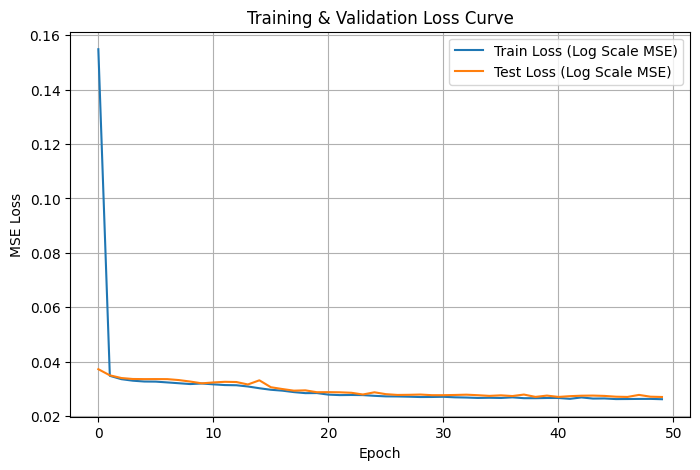


--- Deep Learning Regression Evaluation ---
Mean Absolute Error (MAE): $37365.02
Root Mean Squared Error (RMSE): $55843.03
R² Score (Variance Explained): 0.7620


In [34]:
# 1. Plot Losses
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss (Log Scale MSE)')
plt.plot(test_losses, label='Test Loss (Log Scale MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

# 2. Get Test Set Predictions
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    log_predictions = model(X_test_tensor).cpu().numpy()

# Reverse Log Transformation: exp(y) - 1
predictions_original_scale = np.expm1(log_predictions)
y_test_original_scale = np.expm1(y_test)

# 3. Compute Metrics on Original Dollar Values
mae = mean_absolute_error(y_test_original_scale, predictions_original_scale)
rmse = np.sqrt(mean_squared_error(y_test_original_scale, predictions_original_scale))
r2 = r2_score(y_test_original_scale, predictions_original_scale)

print("\n--- Deep Learning Regression Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae * 100000:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse * 100000:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

In [ ]:
#---------------------------------------
# Step 7: Prediction on Custom Real Estate Data
#---------------------------------------

In [36]:
import pandas as pd

# 1. تفعيل وضع التقييم
model.eval()

# 2. اختيار 5 عينات من مجموعة الاختبار للتحقق من قيمها الحقيقية والتنبؤ بها
num_samples = 5
sample_indices = np.random.choice(len(X_test), size=num_samples, replace=False)

# جلب الخصائص المجهزة والأسعار الحقيقية باللوجاريتم
sample_features_scaled = X_test_scaled[sample_indices]
sample_targets_log = y_test[sample_indices]

# 3. إجراء التنبؤ بوساطة النموذج
sample_tensor = torch.tensor(sample_features_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    log_preds = model(sample_tensor).cpu().numpy()

# 4. إرجاع الأسعار والتوقعات إلى قيمها الأصلية بالدولار
real_prices = np.expm1(sample_targets_log) * 100000
predicted_prices = np.expm1(log_preds) * 100000
errors = np.abs(real_prices - predicted_prices)

# 5. عرض النتائج في جدول مرتب لمقارنة السعر الحقيقي بالسعر المتوقع
results_df = pd.DataFrame({
    'Real Price ($)': real_prices.flatten(),
    'Predicted Price ($)': predicted_prices.flatten(),
    'Absolute Error ($)': errors.flatten()
})

# تنسيق الأرقام بالدولار
results_df['Real Price ($)'] = results_df['Real Price ($)'].apply(lambda x: f"${x:,.2f}")
results_df['Predicted Price ($)'] = results_df['Predicted Price ($)'].apply(lambda x: f"${x:,.2f}")
results_df['Absolute Error ($)'] = results_df['Absolute Error ($)'].apply(lambda x: f"${x:,.2f}")

print("--- مقارنة أداء النموذج على 5 منازل مختلفة ---")
print(results_df.to_string(index=False))

--- مقارنة أداء النموذج على 5 منازل مختلفة ---
Real Price ($) Predicted Price ($) Absolute Error ($)
   $234,600.00         $155,133.42         $79,466.58
   $143,400.00         $151,463.95          $8,063.95
    $62,100.00          $49,017.36         $13,082.64
   $500,001.00         $356,181.62        $143,819.37
   $204,600.00         $212,719.58          $8,119.58
